In [ ]:
# Cell 1 — Mount Drive and install packages
from google.colab import drive
drive.mount('/content/drive')
DRIVE_BASE = '/content/drive/MyDrive/PhishGuard_v2'

import os, subprocess
subprocess.run(['pip', 'install',
    'xgboost==2.1.0', 'shap==0.45.0', 'scikit-learn==1.5.0',
    'pandas==2.2.0', 'numpy==1.26.0', 'joblib==1.4.0', '-q'], check=False)

assert os.path.exists(f'{DRIVE_BASE}/features/wallet_features.csv'), \
    'wallet_features.csv not found — run Notebook 02 first'
assert os.path.exists(f'{DRIVE_BASE}/models/wallet_feature_schema.json'), \
    'wallet_feature_schema.json not found — run Notebook 02 first'
print('Cell 1 ready.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cell 1 ready.


In [17]:
# Cell 2 — Imports and constants
import pandas as pd
import numpy as np
import json
import joblib
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score)

DATA_PATH   = f'{DRIVE_BASE}/features/wallet_features.csv'
SCHEMA_PATH = f'{DRIVE_BASE}/models/wallet_feature_schema.json'
MODEL_PATH  = f'{DRIVE_BASE}/models/wallet_xgboost_v1.pkl'
EVAL_DIR    = f'{DRIVE_BASE}/evaluation'
os.makedirs(EVAL_DIR, exist_ok=True)

RANDOM_SEED = 42
TEST_SIZE   = 0.20

print('Cell 2 imports loaded.')


Cell 2 imports loaded.


In [3]:
# Cell 3 — Load data and validate
df = pd.read_csv(DATA_PATH)
with open(SCHEMA_PATH) as f:
    FEATURE_COLS = json.load(f)

assert df.shape == (4000, 25),                         f'Unexpected shape: {df.shape}'
assert len(FEATURE_COLS) == 23,                        f'Schema has {len(FEATURE_COLS)} features, expected 23'
assert df['label'].value_counts()[1] == 2000,          'Expected 2000 phishing rows'
assert df['label'].value_counts()[0] == 2000,          'Expected 2000 benign rows'
assert df.isnull().sum().sum() == 0,                   'Nulls found in features'
assert not np.isinf(df[FEATURE_COLS].values).any(),    'Inf values found in features'

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['label'].values.astype(np.int32)

print(f'Loaded: {df.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}')


Loaded: (4000, 25)
Features: 23
Class distribution: {0: 2000, 1: 2000}


In [4]:
# Cell 4 — Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'Train: {X_train.shape} — phishing: {y_train.sum():,} | benign: {(y_train==0).sum():,}')
print(f'Test:  {X_test.shape}  — phishing: {y_test.sum():,}  | benign: {(y_test==0).sum():,}')


Train: (3200, 23) — phishing: 1,600 | benign: 1,600
Test:  (800, 23)  — phishing: 400  | benign: 400


In [5]:
# Cell 5 — Train XGBoost model
params = dict(
    n_estimators     = 400,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    scale_pos_weight = 1,     # dataset is balanced — no adjustment needed
    eval_metric      = 'auc',
    random_state     = RANDOM_SEED,
    n_jobs           = -1,
)

model = xgb.XGBClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)
print('Training complete.')


[0]	validation_0-auc:0.99527	validation_1-auc:0.99357
[50]	validation_0-auc:0.99953	validation_1-auc:0.99899
[100]	validation_0-auc:0.99979	validation_1-auc:0.99873
[150]	validation_0-auc:0.99987	validation_1-auc:0.99796
[200]	validation_0-auc:0.99991	validation_1-auc:0.99782
[250]	validation_0-auc:0.99994	validation_1-auc:0.99773
[300]	validation_0-auc:0.99996	validation_1-auc:0.99771
[350]	validation_0-auc:0.99998	validation_1-auc:0.99771
[399]	validation_0-auc:0.99999	validation_1-auc:0.99770
Training complete.


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign     0.9900    0.9950    0.9925       400
    Phishing     0.9950    0.9900    0.9925       400

    accuracy                         0.9925       800
   macro avg     0.9925    0.9925    0.9925       800
weighted avg     0.9925    0.9925    0.9925       800

Confusion matrix — TN: 398  FP: 2  FN: 4  TP: 396
ROC-AUC:       0.9977
Avg Precision: 0.9986
5-fold CV ROC-AUC: 0.9983 ± 0.0012
Per-fold:          [0.9989, 0.996, 0.9993, 0.9987, 0.9985]


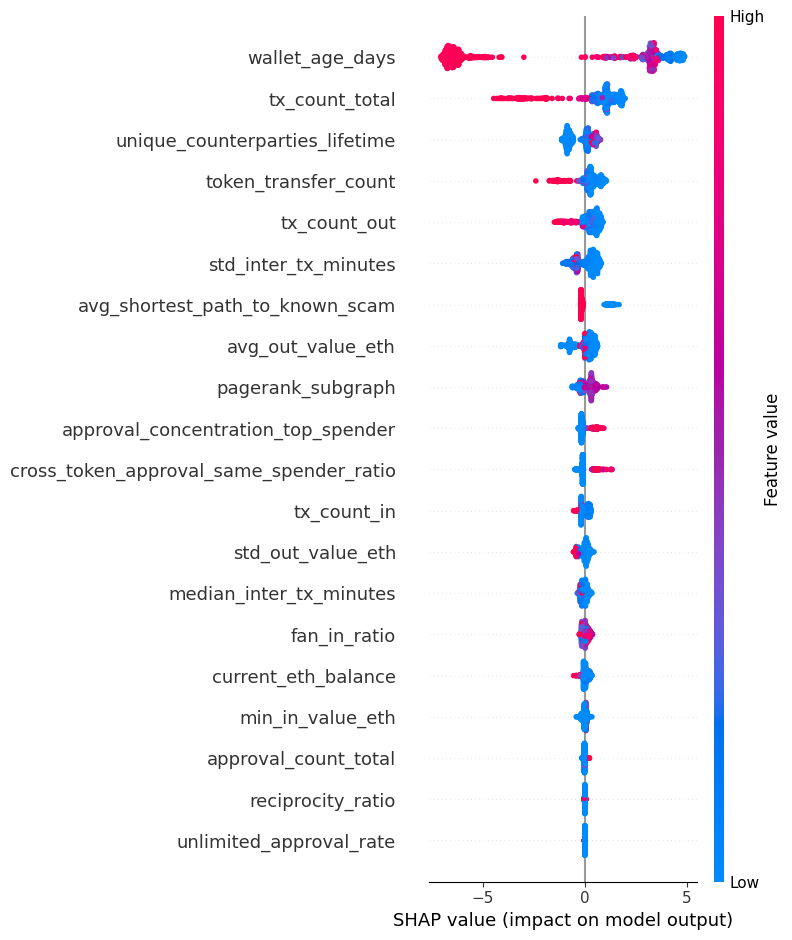

SHAP plot saved: /content/drive/MyDrive/PhishGuard/evaluation/wallet_shap_summary.png


In [6]:
# Cell 6 — Evaluate: metrics, cross-validation, SHAP
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Phishing'], digits=4))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'Confusion matrix — TN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}')

roc_auc  = roc_auc_score(y_test, y_pred_prob)
avg_prec = average_precision_score(y_test, y_pred_prob)
print(f'ROC-AUC:       {roc_auc:.4f}')
print(f'Avg Precision: {avg_prec:.4f}')

# 5-fold stratified CV on full dataset
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(
    xgb.XGBClassifier(**params), X, y,
    cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'5-fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold:          {[round(s, 4) for s in cv_scores]}')

# SHAP summary plot
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.tight_layout()
shap_path = f'{EVAL_DIR}/wallet_shap_summary.png'
plt.savefig(shap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'SHAP plot saved: {shap_path}')


In [7]:
# Cell 7 — Save model and verify
joblib.dump(model, MODEL_PATH)
print(f'Saved: {MODEL_PATH}')

# Reload and verify predictions are identical
model_check  = joblib.load(MODEL_PATH)
y_check      = model_check.predict(X_test)

assert np.array_equal(y_check, y_pred), \
    'Reloaded model predictions differ from original'
assert model_check.n_features_in_ == len(FEATURE_COLS), \
    f'Feature count mismatch: {model_check.n_features_in_} vs {len(FEATURE_COLS)}'

print(f'Verified:             {MODEL_PATH}')
print(f'Model feature count:  {model_check.n_features_in_}')
print(f'XGBoost version:      {xgb.__version__}')
print('Notebook 04 complete.')


Saved: /content/drive/MyDrive/PhishGuard/models/wallet_xgboost_v1.pkl
Verified:             /content/drive/MyDrive/PhishGuard/models/wallet_xgboost_v1.pkl
Model feature count:  23
XGBoost version:      2.1.0
Notebook 04 complete.


In [27]:
import joblib, json, requests, time
import numpy as np
from collections import Counter, defaultdict
import networkx as nx

# ── Load model and schema ─────────────────────────────────────
model = joblib.load(f'{DRIVE_BASE}/models/wallet_xgboost_v1.pkl')
with open(f'{DRIVE_BASE}/models/wallet_feature_schema.json') as f:
    feature_names = json.load(f)

ETHERSCAN_API_KEY = 'WI9RMPKI74VKDCZ8PHUYF1KK36RV8CVZN2'
ETHERSCAN_BASE    = 'https://api.etherscan.io/v2/api'
UNLIMITED         = 2**256 - 1

# ── Etherscan fetch helpers ───────────────────────────────────
def fetch(params):
    try:
        r = requests.get(ETHERSCAN_BASE, params={
            **params, 'chainid': 1, 'apikey': ETHERSCAN_API_KEY
        }, timeout=15)
        time.sleep(0.25)
        data = r.json()
        if data.get('status') == '1':
            return data.get('result', [])
        return []
    except Exception:
        return []

def fetch_wallet_data(address):
    addr = address.lower()
    print(f"Fetching data for {addr}...")

    txs = fetch({'module':'account','action':'txlist',
                 'address':addr,'sort':'desc','offset':500,'page':1})
    print(f"  txs: {len(txs)}")

    tokentxs = fetch({'module':'account','action':'tokentx',
                      'address':addr,'sort':'desc','offset':200,'page':1})
    print(f"  token txs: {len(tokentxs)}")

    logs = fetch({'module':'logs','action':'getLogs','address':addr,
                  'topic0':'0x8c5be1e5ebec7d5bd14f71427d1e84f3dd0314c0f7b2291e5b200ac8c7c3b925',
                  'fromBlock':0,'toBlock':99999999,'offset':1000,'page':1})
    print(f"  approval logs: {len(logs)}")

    balance_result = fetch({'module':'account','action':'balance',
                            'address':addr,'tag':'latest'})
    balance_wei = str(balance_result) if isinstance(balance_result, str) else '0'

    return txs, tokentxs, logs, balance_wei

# ── Feature extraction ────────────────────────────────────────
def extract_features_live(address, txs, tokentxs, logs, balance_wei, scam_set):
    addr = address.lower()
    now  = time.time()

    def safe_divide(n, d, default=0.0):
        return n / d if d != 0 else default

    # Group A
    wallet_age_days = (now - int(txs[-1]['timeStamp'])) / 86400 if txs else 0
    tx_count_in     = sum(1 for t in txs if t.get('to','').lower() == addr)
    tx_count_out    = sum(1 for t in txs if t.get('from','').lower() == addr)
    tx_count_total  = len(txs)

    counterparties = set()
    for t in txs:
        if t.get('from','').lower() != addr: counterparties.add(t.get('from','').lower())
        if t.get('to','').lower()   != addr: counterparties.add(t.get('to','').lower())
    counterparties.discard('')
    unique_counterparties_lifetime = len(counterparties)
    fan_in_ratio = safe_divide(tx_count_in, tx_count_in + tx_count_out, 0.5)

    timestamps = sorted([int(t['timeStamp']) for t in txs if 'timeStamp' in t])
    if len(timestamps) >= 2:
        diffs = np.diff(timestamps)
        median_inter_tx_minutes = float(np.median(diffs)) / 60
        std_inter_tx_minutes    = float(np.std(diffs, ddof=0)) / 60
    else:
        median_inter_tx_minutes = std_inter_tx_minutes = 0

    # Group B
    out_vals = [int(t.get('value',0))/1e18 for t in txs
                if t.get('from','').lower()==addr and t.get('isError')=='0'
                and int(t.get('value',0))>0]
    avg_out_value_eth = float(np.mean(out_vals))        if out_vals          else 0
    std_out_value_eth = float(np.std(out_vals, ddof=0)) if len(out_vals)>=2  else 0

    in_vals = [int(t.get('value',0))/1e18 for t in txs
               if t.get('to','').lower()==addr and t.get('isError')=='0']
    min_in_value_eth    = float(min(in_vals)) if in_vals else 0
    current_eth_balance = float(balance_wei) / 1e18

    # Group C
    def parse_amount(log):
        topics = log.get('topics', [])
        data   = log.get('data', '0x')
        try:
            if len(topics) == 3:
                return int(data, 16) if data and data != '0x' else 0
            elif len(topics) == 4:
                return int(topics[3], 16) if topics[3] else 0
        except Exception:
            pass
        return 0

    approval_count_total              = len(logs)
    unlimited_count                   = sum(1 for l in logs if parse_amount(l) == UNLIMITED)
    unlimited_approval_count_lifetime = unlimited_count
    spenders = ['0x' + l['topics'][2][-40:] for l in logs if len(l.get('topics',[])) >= 3]
    unique_spenders_lifetime          = len(set(spenders))

    if approval_count_total > 0:
        sc = Counter(spenders)
        approval_concentration_top_spender = safe_divide(
            sc.most_common(1)[0][1], approval_count_total)
    else:
        approval_concentration_top_spender = 0

    unlimited_approval_rate  = safe_divide(unlimited_count, approval_count_total)
    token_transfer_count     = len(tokentxs)

    if unique_spenders_lifetime > 0:
        spender_tokens = defaultdict(set)
        for l in logs:
            if len(l.get('topics',[])) >= 3:
                spender = '0x' + l['topics'][2][-40:]
                spender_tokens[spender].add(l.get('address','').lower())
        multi = sum(1 for t in spender_tokens.values() if len(t) > 1)
        cross_token_approval_same_spender_ratio = safe_divide(multi, unique_spenders_lifetime)
    else:
        cross_token_approval_same_spender_ratio = 0

    # Group D — graph features
    try:
        recent = [t for t in txs[:100] if t.get('isError') == '0']
        G = nx.DiGraph()
        for tx in recent:
            frm = tx.get('from','').lower()
            to  = tx.get('to','').lower()
            if frm and to:
                G.add_edge(frm, to, weight=int(tx.get('value',0))/1e18)

        if G.number_of_edges() > 0 and addr in G.nodes():
            pr          = nx.pagerank(G, alpha=0.85)
            pagerank    = pr.get(addr, 0.0)
            G_und       = G.to_undirected()
            cc          = nx.clustering(G_und)
            clustering  = cc.get(addr, 0.0)
            succ        = set(G.successors(addr))
            pred        = set(G.predecessors(addr))
            mutual      = succ & pred
            all_nb      = succ | pred
            reciprocity = safe_divide(len(mutual), len(all_nb))
            scam_nodes  = [n for n in G_und.nodes() if n in scam_set]
            if scam_nodes:
                paths = []
                for sn in scam_nodes:
                    try:
                        paths.append(nx.shortest_path_length(G_und, addr, sn))
                    except Exception:
                        pass
                avg_scam_path = float(np.mean(paths)) if paths else 99.0
            else:
                avg_scam_path = 99.0
        else:
            pagerank = clustering = reciprocity = 0.0
            avg_scam_path = 99.0
    except Exception:
        pagerank = clustering = reciprocity = 0.0
        avg_scam_path = 99.0

    return {
        'wallet_age_days':                         wallet_age_days,
        'tx_count_in':                             tx_count_in,
        'tx_count_out':                            tx_count_out,
        'tx_count_total':                          tx_count_total,
        'unique_counterparties_lifetime':          unique_counterparties_lifetime,
        'fan_in_ratio':                            fan_in_ratio,
        'median_inter_tx_minutes':                 median_inter_tx_minutes,
        'std_inter_tx_minutes':                    std_inter_tx_minutes,
        'avg_out_value_eth':                       avg_out_value_eth,
        'std_out_value_eth':                       std_out_value_eth,
        'min_in_value_eth':                        min_in_value_eth,
        'current_eth_balance':                     current_eth_balance,
        'approval_count_total':                    approval_count_total,
        'unlimited_approval_count_lifetime':       unlimited_approval_count_lifetime,
        'unique_spenders_lifetime':                unique_spenders_lifetime,
        'approval_concentration_top_spender':      approval_concentration_top_spender,
        'unlimited_approval_rate':                 unlimited_approval_rate,
        'token_transfer_count':                    token_transfer_count,
        'cross_token_approval_same_spender_ratio': cross_token_approval_same_spender_ratio,
        'pagerank_subgraph':                       pagerank,
        'clustering_coefficient':                  clustering,
        'reciprocity_ratio':                       reciprocity,
        'avg_shortest_path_to_known_scam':         avg_scam_path,
    }

# ── Main predict function ─────────────────────────────────────
def predict_live(address):
    # Load scam set
    with open(f'{DRIVE_BASE}/data/scam_addresses.json') as f:
        scam_set = set(json.load(f))

    txs, tokentxs, logs, balance_wei = fetch_wallet_data(address)

    if not txs:
        print("No transactions found — cannot classify.")
        return

    features = extract_features_live(
        address, txs, tokentxs, logs, balance_wei, scam_set)

    X = np.array([[features[f] for f in feature_names]], dtype=np.float32)
    prob = model.predict_proba(X)[0][1]
    pred = "🚨 PHISHING" if prob >= 0.5 else "✅ BENIGN"

    print(f"\n{'='*50}")
    print(f"Address:    {address.lower()}")
    print(f"Prediction: {pred}")
    print(f"Confidence: {prob*100:.2f}% phishing probability")
    print(f"{'='*50}")
    print(f"\nKey features:")
    for feat in ['wallet_age_days','approval_count_total',
                 'unlimited_approval_rate','avg_shortest_path_to_known_scam',
                 'cross_token_approval_same_spender_ratio']:
        print(f"  {feat:<45} {features[feat]:.4f}")

# ── Test it ───────────────────────────────────────────────────
predict_live("0xEE368f5cBc42D4Df657e1a0ec8f16027263d35e1")

Fetching data for 0xee368f5cbc42d4df657e1a0ec8f16027263d35e1...
  txs: 217
  token txs: 200
  approval logs: 0

Address:    0xee368f5cbc42d4df657e1a0ec8f16027263d35e1
Prediction: 🚨 PHISHING
Confidence: 91.79% phishing probability

Key features:
  wallet_age_days                               872.0889
  approval_count_total                          0.0000
  unlimited_approval_rate                       0.0000
  avg_shortest_path_to_known_scam               99.0000
  cross_token_approval_same_spender_ratio       0.0000
